First 5 Rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  


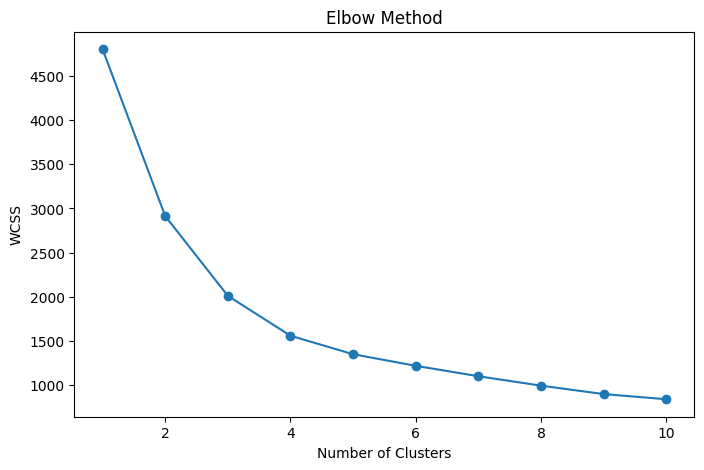

K=2, Silhouette Score=0.3440
K=3, Silhouette Score=0.3498
K=4, Silhouette Score=0.3328
K=5, Silhouette Score=0.3080
K=6, Silhouette Score=0.2858
K=7, Silhouette Score=0.2776
K=8, Silhouette Score=0.2911
K=9, Silhouette Score=0.2926
K=10, Silhouette Score=0.2847

Cluster Counts:
Cluster
1    333
2    300
3    284
0    283
Name: count, dtype: int64


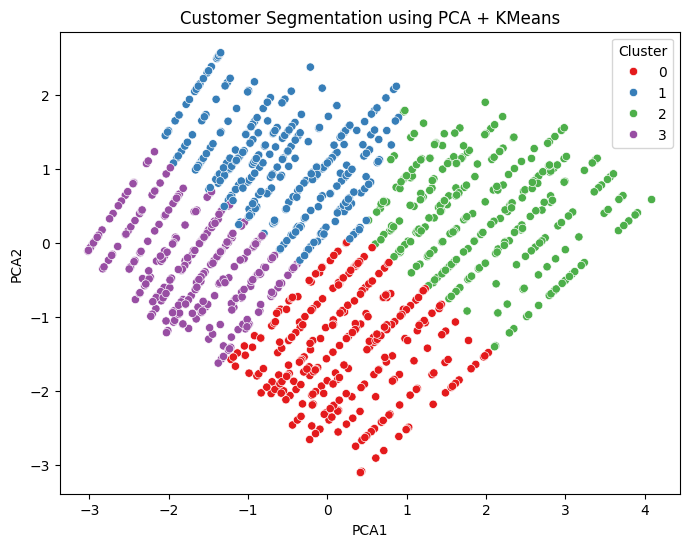


Cluster Summary:
         Quantity   UnitPrice  ItemsInCart   TotalPrice
Cluster                                                
0        4.151943  182.210919     7.155477   747.307880
1        1.849850  499.624625     3.963964   902.096126
2        4.193333  536.006400     7.043333  2230.833733
3        1.711268  172.368627     3.957746   294.456690

Business Personas:
Cluster 0 → Budget Customers
Cluster 1 → Premium Customers
Cluster 2 → Frequent Buyers
Cluster 3 → High Value Customers


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# -----------------------------
# STEP 1: Load Dataset
# -----------------------------
df = pd.read_excel("Dataset for Data Analytics.xlsx")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

# -----------------------------
# STEP 2: Handle Missing Values
# -----------------------------
df.replace(["NA", "Unknown", ""], np.nan, inplace=True)

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df = df.drop_duplicates()

# -----------------------------
# STEP 3: Select Features for Clustering
# -----------------------------
features = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
X = df[features]

# -----------------------------
# STEP 4: Scale Data
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# STEP 5: Elbow Method
# -----------------------------
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# -----------------------------
# STEP 6: Silhouette Score
# -----------------------------
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

# -----------------------------
# STEP 7: Final KMeans (Choose best K)
# -----------------------------
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nCluster Counts:")
print(df['Cluster'].value_counts())

# -----------------------------
# STEP 8: Apply PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# -----------------------------
# STEP 9: Visualize Clusters
# -----------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['Cluster'], palette='Set1')
plt.title("Customer Segmentation using PCA + KMeans")
plt.show()

# -----------------------------
# STEP 10: Cluster Summary
# -----------------------------
cluster_summary = df.groupby('Cluster')[features].mean()
print("\nCluster Summary:")
print(cluster_summary)

# -----------------------------
# STEP 11: Business Personas
# -----------------------------
print("\nBusiness Personas:")
print("Cluster 0 → Budget Customers")
print("Cluster 1 → Premium Customers")
print("Cluster 2 → Frequent Buyers")
print("Cluster 3 → High Value Customers")